This is an example on predicting salaries (regression).

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
# 1. Load the CSV file
df = pd.read_csv("regression.csv")

# Check the first few rows
print(df.head())

# 2. Check column types
print(df.dtypes)

   TotalWorkingYears    JobRole  MonthlyIncome
0                8.9    Manager        5993.67
1               10.6  Executive        5130.92
2                7.9  Executive        2090.84
3                8.5  Executive        2909.54
4                6.7  Executive        3468.88
TotalWorkingYears    float64
JobRole               object
MonthlyIncome        float64
dtype: object


In [6]:
# 3. One-hot encode the categorical variable 'JobRole'
df_encoded = pd.get_dummies(df, columns=['JobRole'], drop_first=True)

print(df_encoded.head())

   TotalWorkingYears  MonthlyIncome  JobRole_Executive  JobRole_Manager
0                8.9        5993.67              False             True
1               10.6        5130.92               True            False
2                7.9        2090.84               True            False
3                8.5        2909.54               True            False
4                6.7        3468.88               True            False


In [7]:
# 4. Define predictors (X) and target (y)
X = df_encoded.drop("MonthlyIncome", axis=1)
y = df_encoded["MonthlyIncome"]

In [8]:
# 5. Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

In [9]:
# 6. Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
# 7. Make predictions
y_pred = model.predict(X_test)

In [11]:
# 8. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Squared Error: 2545452.86
R-squared: 0.89


In [12]:
# 9. Show model coefficients
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(coeff_df)

             Feature   Coefficient
0  TotalWorkingYears    203.848441
1  JobRole_Executive -10151.595998
2    JobRole_Manager  -7167.436547


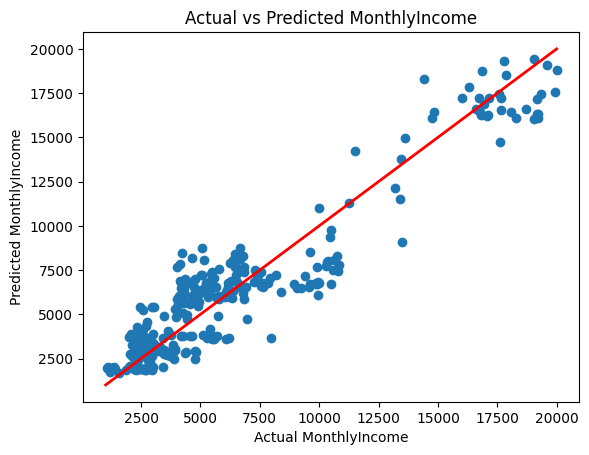

In [13]:
# 10. Visualize actual vs predicted
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual MonthlyIncome")
plt.ylabel("Predicted MonthlyIncome")
plt.title("Actual vs Predicted MonthlyIncome")
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linewidth=2)
plt.show()

In [26]:
# 11. Prediction with new data
new_data_raw = pd.DataFrame({
    'TotalWorkingYears': [5],
    'JobRole': ['Sales']  # categorical, raw
})

# Apply same one-hot encoding as training
new_data_encoded = pd.get_dummies(new_data_raw, columns=['JobRole'])

# Ensure all training columns exist
for col in X.columns:
    if col not in new_data_encoded.columns:
        new_data_encoded[col] = False

# Reorder to match training data
new_data_encoded = new_data_encoded[X.columns]

print(new_data_raw)
print(new_data_encoded)

# Actually there is a bug here. Can you identify it? How to fix it?

   TotalWorkingYears JobRole
0                  5   Sales
   TotalWorkingYears  JobRole_Executive  JobRole_Manager
0                  5              False            False


In [23]:
# Predict 
predicted_income = model.predict(new_data_encoded)
print(f"Predicted MonthlyIncome: {predicted_income[0]:.2f}")

Predicted MonthlyIncome: 5631.76
